# Correlating C02 Emissions and Global Temperature Anomalies

## Import Modules and Define variables

In [ ]:
import plotly.express as px
import pandas as pd


# Define variables
start_year = 1850
end_year = 2021
START_YEAR = 1850
END_YEAR = 2021
coefficient_of_correlation=0


## Bar Chart Temperature Anomalies (1850-2021)
This data is available for years 1751-2021, but filtered to 1850-2021 in order to compare with tempature anomoly data.

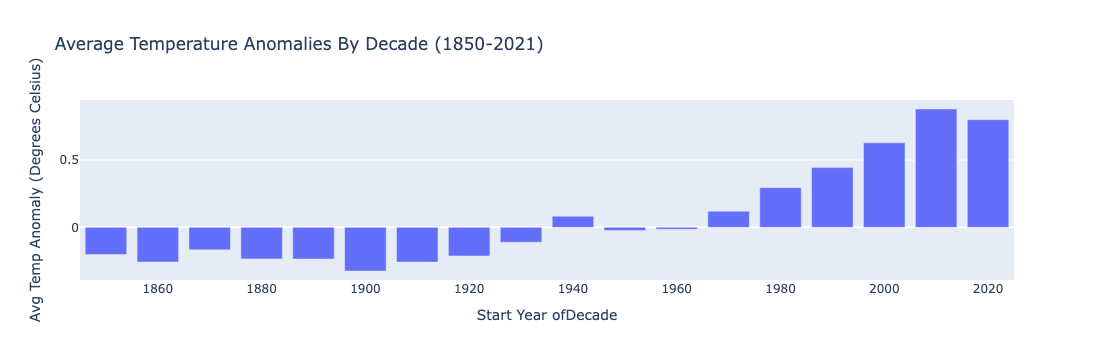

In [4]:
# BAR CHART: Temperature Anomalies by Year

# Temp Anomalies Filtering
TEMP_ANOMALIES_DATA = '../data/global_temp_anomaly.csv'
# Read temp anomaly data
df_temp_anomaly = pd.read_csv(TEMP_ANOMALIES_DATA,comment='#',encoding='utf8')

# filter data for the specified year range (1850-2021)
df_filtered_temp_anomalies_1850_2021 = \
    df_temp_anomaly[(df_temp_anomaly\
    ['Year']>= START_YEAR) & (df_temp_anomaly['Year'] <= END_YEAR)]

# set up title constant
TEMP_ANOMALIES_TITLE = 'Average Temperature Anomalies By Decade (1850-2021)' 
# set up filtering with column name constant
ANOMALY_COL_NAME = 'Anomaly'

# Create bins to feed bar chart
# Create a copy to add binned data to
df_filtered_temp_anomalies_1850_2021_COPY = df_filtered_temp_anomalies_1850_2021.copy()
# Create bins for decades - make the end year 1 greater than the last year to include
bins = pd.interval_range(start=1850, end=2030, freq=10, closed='right')  # 10-year bins
# Add a final bin to cover 2021
# bins = bins.append(pd.Interval(left=2020, right=2021, closed='right'))
# print(bins)

# Add a new column to the DataFrame with the binned years
df_filtered_temp_anomalies_1850_2021_COPY['Year_bin'] = pd.cut(\
    df_filtered_temp_anomalies_1850_2021_COPY['Year'], bins)
# print(df_filtered_temp_anomalies_1850_2021_COPY)

# Group by bin and calculate mean anomaly
grouped = df_filtered_temp_anomalies_1850_2021_COPY.groupby('Year_bin', observed=True)['Anomaly'].mean().reset_index()
# print(grouped)

# Plot with Plotly Express
# Convert Interval to string for better x-axis labeling 
# and allowing Plotly to serialze it
#######grouped['Year_bin'] = grouped['Year_bin'].astype(str)
grouped['Year_bin_start'] = grouped['Year_bin']\
    .apply(lambda x: int(x.left))
bar_fig = px.bar(grouped, x='Year_bin_start', y='Anomaly', title=TEMP_ANOMALIES_TITLE)

# bar_fig = px.bar(grouped, x='Year_bin', y='Anomaly', title='Average Temperature Anomaly by Decade')
BAR_Y_AXIS_TITLE = "Avg Temp Anomaly\n(Degrees Celsius)"
BAR_X_AXIS_TITLE = "Start Year ofDecade"
bar_fig.update_layout(xaxis_title=BAR_X_AXIS_TITLE)
bar_fig.update_layout(yaxis_title=BAR_Y_AXIS_TITLE)
bar_fig.show()
bar_fig.write_html('bar_chart_temp_anomalies_1850_2021.html')

